# Phase 5: Full Path A Pipeline Integration
## Smart Document Extraction Pipeline

**Kaggle Notebook** | CPU or GPU | ~1 hour runtime

---

### Before Running
1. **Phase 4 Dataset**: Add Data -> Your Datasets -> `sdep-phase-4-output` -> Add
2. **SROIE Dataset**: Add Data -> `SROIE datasetv2` by urbikn -> Add
3. **Internet**: ON
4. **Accelerator**: T4 GPU (YOLO faster on GPU, LayoutLMv3 CPU-feasible)

---

### What This Phase Builds

```
Path A End-to-End:
  Image
    -> layout_detector.py   (YOLO26 -> region bboxes)
    -> ocr_engine.py        (Tesseract -> words + bboxes per region)
    -> kie_model.py         (LayoutLMv3 -> field labels per token)
    -> json_structurer.py   (group tokens -> Pydantic JSON)
    -> visualiser.py        (OpenCV annotated overlay)
    -> pipeline.py          (orchestrates all stages)
```

| Cell | Task | Output |
|------|------|--------|
| 2-4 | Install, imports, paths | Environment ready |
| 5 | Write `layout_detector.py` | YOLO26 wrapper |
| 6 | Write `json_structurer.py` | Token grouping + Pydantic |
| 7 | Write `visualiser.py` | OpenCV overlay |
| 8 | Write `pipeline.py` | Full orchestration |
| 9-10 | Test end-to-end on 10 SROIE receipts | JSON + overlay images |
| 11 | Latency breakdown per stage | Timing table |
| 12 | Visualize annotated overlays | 6-image grid |
| 13 | Evaluate extracted fields vs SROIE GT | Field accuracy |
| 14-15 | Save all results + src files | Phase 6 ready |

In [1]:
# Cell 2: Install dependencies
!pip install ultralytics>=8.3.0 -q
!pip install transformers>=4.40.0 datasets>=2.19.0 -q
!pip install opencv-python Pillow pydantic pandas matplotlib tqdm -q
!pip install pytesseract -q
!apt-get install -y tesseract-ocr -q
print('Phase 5 dependencies installed')

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 124 not upgraded.
Phase 5 dependencies installed


In [2]:
# Cell 3: Imports
import os, json, shutil, time, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import torch
from PIL import Image, ImageDraw
from tqdm import tqdm

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

n_gpus = torch.cuda.device_count()
YOLO_DEVICE = '0' if n_gpus > 0 else 'cpu'
KIE_DEVICE  = 'cuda' if n_gpus > 0 else 'cpu'
print(f'YOLO device: {YOLO_DEVICE}')
print(f'KIE device:  {KIE_DEVICE}')

YOLO device: 0
KIE device:  cuda


In [3]:
# Cell 4: Path setup + copy all Phase 4 src assets forward
PHASE4_DIR  = Path('/kaggle/input/datasets/daudshah/sdep-phase-4-output/doc-extraction-pipeline')
SROIE_ROOT  = Path('/kaggle/input/datasets/urbikn/sroie-datasetv2')
WORKING_DIR = Path('/kaggle/working/doc-extraction-pipeline')
SRC_DIR     = WORKING_DIR / 'src'
RESULTS_DIR = WORKING_DIR / 'results'
OUTPUTS_DIR = WORKING_DIR / 'outputs'
MODELS_DIR  = WORKING_DIR / 'models'

for d in [SRC_DIR, RESULTS_DIR,
          OUTPUTS_DIR / 'annotated',
          OUTPUTS_DIR / 'json',
          MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Copy all src files from Phase 4
p4_src = PHASE4_DIR / 'src'
if p4_src.exists():
    for f in p4_src.iterdir():
        shutil.copy2(f, SRC_DIR / f.name)
    print(f'Copied src: {sorted([f.name for f in p4_src.iterdir()])}')

# Copy results
p4_res = PHASE4_DIR / 'results'
if p4_res.exists():
    for f in p4_res.iterdir():
        shutil.copy2(f, RESULTS_DIR / f.name)
    print(f'Copied results: {sorted([f.name for f in p4_res.iterdir()])}')

# Key model paths
PHASE2_DIR = Path('/kaggle/input/datasets/daudshah/sdep-phase-2-output/doc-extraction-pipeline')
YOLO_PT    = PHASE2_DIR / 'models/yolo26_doclaynet/yolo26_doclaynet_best.pt'
KIE_DIR    = PHASE4_DIR / 'models/layoutlmv3_cord/best'

print(f'YOLO checkpoint: {YOLO_PT}')
print(f'  Exists: {YOLO_PT.exists()}')
print(f'KIE checkpoint:  {KIE_DIR}')
print(f'  Exists: {KIE_DIR.exists()}')

print(f'\nYOLO checkpoint: {YOLO_PT.exists()}')
print(f'KIE checkpoint:  {KIE_DIR.exists()}')

# SROIE test images + ground truth
test_imgs = sorted(SROIE_ROOT.rglob('*.jpg'))[:50]
print(f'SROIE test images: {len(test_imgs)}')

Copied src: ['kie_model.py', 'ocr_engine.py', 'schema.py']
Copied results: ['phase2_results.json', 'phase2_summary.md', 'phase3_example_output.json', 'phase3_results.json', 'phase3_summary.md', 'phase4_results.json', 'phase4_summary.md']
YOLO checkpoint: /kaggle/input/datasets/daudshah/sdep-phase-2-output/doc-extraction-pipeline/models/yolo26_doclaynet/yolo26_doclaynet_best.pt
  Exists: True
KIE checkpoint:  /kaggle/input/datasets/daudshah/sdep-phase-4-output/doc-extraction-pipeline/models/layoutlmv3_cord/best
  Exists: True

YOLO checkpoint: True
KIE checkpoint:  True
SROIE test images: 50


In [4]:
# Cell 5: Write src/layout_detector.py
# YOLO26 wrapper -- detects layout regions, returns sorted bboxes

LAYOUT_CODE = '''
"""layout_detector.py -- Phase 5
YOLO26 layout detection wrapper for Path A.
Returns region bboxes sorted top-to-bottom for natural reading order.
"""
import time
import numpy as np
from pathlib import Path
from PIL import Image
from ultralytics import YOLO

YOLO_CLASSES = ["Text", "Table", "Section-header", "Title", "Picture"]


class LayoutDetector:
    def __init__(self, checkpoint_path, device="cpu", conf=0.25, iou=0.45):
        self.model   = YOLO(str(checkpoint_path))
        self.device  = device
        self.conf    = conf
        self.iou     = iou
        self.classes = YOLO_CLASSES

    def detect(self, image_path):
        """
        Run YOLO26 on one image.
        Returns list of region dicts sorted by y1 (top-to-bottom reading order).
        Each region: {class_name, bbox:[x1,y1,x2,y2], confidence}
        """
        t0 = time.time()
        result = self.model.predict(
            source  = str(image_path),
            imgsz   = 640,
            conf    = self.conf,
            iou     = self.iou,
            device  = self.device,
            verbose = False,
        )[0]
        latency_ms = (time.time() - t0) * 1000

        regions = []
        if result.boxes is not None and len(result.boxes) > 0:
            boxes   = result.boxes.xyxy.cpu().numpy()
            cls_ids = result.boxes.cls.cpu().numpy().astype(int)
            confs   = result.boxes.conf.cpu().numpy()
            for box, cls_id, conf in zip(boxes, cls_ids, confs):
                cls_name = self.classes[cls_id] if cls_id < len(self.classes) else str(cls_id)
                regions.append({
                    "class_name":  cls_name,
                    "bbox":        [float(v) for v in box],
                    "confidence":  round(float(conf), 4),
                })

        # Sort top-to-bottom (reading order)
        regions.sort(key=lambda r: r["bbox"][1])
        return regions, latency_ms

    def fallback_regions(self, image):
        """
        When YOLO finds nothing: treat entire image as one Text region.
        This ensures OCR + KIE still run on every document.
        """
        w, h = image.size
        return [{
            "class_name": "Text",
            "bbox":       [0.0, 0.0, float(w), float(h)],
            "confidence": 0.5,
        }]
'''

(SRC_DIR / 'layout_detector.py').write_text(LAYOUT_CODE.strip())
print(f'layout_detector.py written')

layout_detector.py written


In [5]:
# Cell 6: Write src/json_structurer.py
# Groups LayoutLMv3 token predictions into Pydantic-validated JSON

STRUCTURER_CODE = '''
"""json_structurer.py -- Phase 5
Groups token-level KIE predictions into the DocumentExtraction schema.
"""
import re
from collections import defaultdict
from typing import List, Dict, Any
import sys
from pathlib import Path
sys.path.insert(0, str(Path(__file__).parent))
from schema import (
    DocumentExtraction, VendorInfo, DocumentMeta,
    LineItem, Totals, Payment, ExtractionMeta,
)


def _to_float(text: str) -> float:
    """Convert receipt number strings to float. Handles commas and dots."""
    cleaned = re.sub(r"[^\d.,]", "", text.strip())
    cleaned = cleaned.replace(",", ".")
    # If multiple dots, keep only last (e.g. 1.234.56 -> 1234.56)
    parts = cleaned.split(".")
    if len(parts) > 2:
        cleaned = "".join(parts[:-1]) + "." + parts[-1]
    try:
        return round(float(cleaned), 2)
    except (ValueError, TypeError):
        return 0.0


def _join_tokens(token_list: List[str]) -> str:
    """Join SentencePiece subword tokens back into readable text."""
    text = ""
    for tok in token_list:
        tok = tok.replace("\u2581", " ").strip()
        if not tok:
            continue
        text = (text + " " + tok) if text else tok
    return text.strip()


def structure(
    token_predictions: List[Dict],
    field_confidences: Dict[str, float],
    yolo_ms: float = 0,
    ocr_ms: float = 0,
    kie_ms: float = 0,
) -> DocumentExtraction:
    """
    Convert LayoutLMv3 per-token predictions to a DocumentExtraction.

    Args:
        token_predictions: list from KIEModel.predict()
            each item: {token, label, confidence}
        field_confidences: dict of {field_name: mean_confidence}
        yolo_ms, ocr_ms, kie_ms: per-stage latencies

    Returns:
        DocumentExtraction (Pydantic-validated)
    """
    # ── Group tokens by field type ───────────────────────────────────
    field_tokens: Dict[str, List[str]] = defaultdict(list)

    for item in token_predictions:
        label = item.get("label", "O")
        token = item.get("token", "")
        if label == "O" or not token:
            continue
        field = label.replace("B-", "").replace("I-", "")
        field_tokens[field].append(token)

    def get(field: str) -> str:
        return _join_tokens(field_tokens.get(field, []))

    # ── Build line items (group by contiguous ITEM_NAME spans) ───────
    line_items = []
    name_text  = get("ITEM_NAME")
    price_text = get("ITEM_PRICE")
    qty_text   = get("ITEM_QTY")

    if name_text or price_text:
        line_items.append(LineItem(
            description = name_text,
            quantity    = _to_float(qty_text) if qty_text else 1.0,
            unit_price  = _to_float(price_text),
            total       = _to_float(price_text),
        ))

    # ── Build totals ─────────────────────────────────────────────────
    totals = Totals(
        subtotal = _to_float(get("SUBTOTAL")),
        tax      = _to_float(get("TAX")),
        discount = _to_float(get("DISCOUNT")),
        total    = _to_float(get("TOTAL")),
    )

    # ── Build payment ────────────────────────────────────────────────
    payment_text = get("PAYMENT")
    payment = Payment(
        method      = "",
        amount_paid = _to_float(payment_text),
        change      = 0.0,
    )

    # ── Extraction metadata ──────────────────────────────────────────
    total_ms = int(yolo_ms + ocr_ms + kie_ms)
    meta     = ExtractionMeta(
        model_path         = "path_a",
        processing_time_ms = total_ms,
        ocr_engine         = "tesseract",
        layout_model       = "yolo26_doclaynet",
        kie_model          = "layoutlmv3_cord",
    )

    # ── Assemble and validate ────────────────────────────────────────
    doc = DocumentExtraction(
        vendor          = VendorInfo(),
        document        = DocumentMeta(),
        line_items      = line_items,
        totals          = totals,
        payment         = payment,
        extraction_meta = meta,
    )
    doc.flag_low_confidence(field_confidences)
    return doc
'''

(SRC_DIR / 'json_structurer.py').write_text(STRUCTURER_CODE.strip())
print('json_structurer.py written')

json_structurer.py written


In [6]:
# Cell 7: Write src/visualiser.py
# OpenCV annotated overlay -- draws region boxes + field labels on receipt

VIS_CODE = '''
"""visualiser.py -- Phase 5
OpenCV-based annotated overlay for Path A pipeline output.
Draws YOLO region boxes and KIE field labels on the source image.
"""
import cv2
import numpy as np
from PIL import Image
from pathlib import Path

# Color palette per layout class (BGR for OpenCV)
REGION_COLORS = {
    "Text":           (219, 152,  52),
    "Table":          (113, 204,  46),
    "Section-header": ( 60,  76, 231),
    "Title":          ( 15, 196, 241),
    "Picture":        (182,  89, 155),
}
DEFAULT_COLOR = (128, 128, 128)

# Color palette per KIE field (BGR)
FIELD_COLORS = {
    "ITEM_NAME":  ( 46, 204, 113),
    "ITEM_QTY":   (241, 196,  15),
    "ITEM_PRICE": (231,  76,  60),
    "SUBTOTAL":   ( 52, 152, 219),
    "TAX":        (155,  89, 182),
    "DISCOUNT":   ( 26, 188, 156),
    "TOTAL":      (  0,   0, 255),
    "PAYMENT":    ( 39, 174,  96),
}


def draw_pipeline_output(
    image_path,
    regions,
    pipeline_output,
    extraction,
    save_path=None,
):
    """
    Draw full Path A output on the receipt image.

    Args:
        image_path:       path to original receipt image
        regions:          list of region dicts from LayoutDetector
        pipeline_output:  dict from OCREngine.run_pipeline()
        extraction:       DocumentExtraction Pydantic object
        save_path:        if set, saves annotated image here

    Returns:
        annotated image as numpy BGR array
    """
    img = cv2.imread(str(image_path))
    if img is None:
        pil = Image.open(image_path).convert("RGB")
        img = cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR)

    overlay = img.copy()

    # ── Draw YOLO region boxes ───────────────────────────────────────
    for region in regions:
        x1, y1, x2, y2 = [int(v) for v in region["bbox"]]
        cls_name = region["class_name"]
        color    = REGION_COLORS.get(cls_name, DEFAULT_COLOR)

        cv2.rectangle(overlay, (x1, y1), (x2, y2), color, 2)

        # Class label tag
        label = f'{cls_name} {region["confidence"]:.2f}'
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
        cv2.rectangle(overlay, (x1, y1 - th - 6), (x1 + tw + 4, y1), color, -1)
        cv2.putText(overlay, label, (x1 + 2, y1 - 3),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)

    # ── Draw OCR word boxes (faint) ──────────────────────────────────
    for idx, region_data in pipeline_output.items():
        cls_name = region_data.get("region_class", "Text")
        color    = REGION_COLORS.get(cls_name, DEFAULT_COLOR)
        for word in region_data.get("words", []):
            bx1, by1, bx2, by2 = [int(v) for v in word["xyxy_bbox"]]
            cv2.rectangle(overlay, (bx1, by1), (bx2, by2), color, 1)

    # ── Blend overlay with original ──────────────────────────────────
    result = cv2.addWeighted(overlay, 0.75, img, 0.25, 0)

    # ── Summary panel on the right ───────────────────────────────────
    h, w = result.shape[:2]
    panel_w = max(280, w // 3)
    panel   = np.zeros((h, panel_w, 3), dtype=np.uint8)
    panel[:] = (30, 30, 30)  # dark background

    y_cursor = 20
    cv2.putText(panel, "EXTRACTED FIELDS", (8, y_cursor),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
    y_cursor += 20
    cv2.line(panel, (8, y_cursor), (panel_w - 8, y_cursor), (80, 80, 80), 1)
    y_cursor += 14

    ext = extraction
    fields_to_show = [
        ("Total",    f'{ext.totals.total:.2f}',    "TOTAL"),
        ("Subtotal", f'{ext.totals.subtotal:.2f}', "SUBTOTAL"),
        ("Tax",      f'{ext.totals.tax:.2f}',      "TAX"),
        ("Discount", f'{ext.totals.discount:.2f}', "DISCOUNT"),
        ("Payment",  f'{ext.payment.amount_paid:.2f}', "PAYMENT"),
    ]

    for field_name, value, color_key in fields_to_show:
        if y_cursor > h - 30:
            break
        color = FIELD_COLORS.get(color_key, (200, 200, 200))
        cv2.putText(panel, f'{field_name}:', (8, y_cursor),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.42, (160, 160, 160), 1)
        cv2.putText(panel, value, (100, y_cursor),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.42, color, 1)
        y_cursor += 18

    y_cursor += 10
    cv2.putText(panel,
                f'Conf: {ext.extraction_meta.overall_confidence:.2f}',
                (8, y_cursor), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (120, 200, 120), 1)
    y_cursor += 16
    cv2.putText(panel,
                f'Time: {ext.extraction_meta.processing_time_ms}ms',
                (8, y_cursor), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (120, 200, 120), 1)

    if ext.extraction_meta.low_confidence_fields:
        y_cursor += 16
        cv2.putText(panel, "Low conf:", (8, y_cursor),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.38, (0, 100, 255), 1)
        for lf in ext.extraction_meta.low_confidence_fields[:3]:
            y_cursor += 14
            cv2.putText(panel, f"  {lf}", (8, y_cursor),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.36, (0, 150, 255), 1)

    # Concatenate receipt + panel
    if result.shape[0] != panel.shape[0]:
        panel = cv2.resize(panel, (panel_w, result.shape[0]))
    final = np.hstack([result, panel])

    if save_path:
        cv2.imwrite(str(save_path), final)

    return final
'''

(SRC_DIR / 'visualiser.py').write_text(VIS_CODE.strip())
print('visualiser.py written')

visualiser.py written


In [7]:
# Cell 8: Write src/pipeline.py -- full Path A orchestration
PIPELINE_CODE = '''
"""pipeline.py -- Phase 5
Path A end-to-end orchestration.
  Image -> LayoutDetector -> OCREngine -> KIEModel -> JSONStructurer
"""
import time
import json
from pathlib import Path
from collections import defaultdict
from PIL import Image
import sys
sys.path.insert(0, str(Path(__file__).parent))

from layout_detector import LayoutDetector
from ocr_engine      import OCREngine
from kie_model       import KIEModel
from json_structurer import structure
from visualiser      import draw_pipeline_output


class PathAPipeline:
    def __init__(
        self,
        yolo_checkpoint,
        kie_checkpoint,
        yolo_device = "cpu",
        kie_device  = "cpu",
        yolo_conf   = 0.25,
    ):
        print("Loading LayoutDetector...")
        self.detector = LayoutDetector(yolo_checkpoint, device=yolo_device, conf=yolo_conf)

        print("Loading OCREngine...")
        self.ocr = OCREngine(lang="en", use_gpu=False)

        print(f"Loading KIEModel on {kie_device}...")
        self.kie = KIEModel(kie_checkpoint, device=kie_device)

        print("Pipeline ready")

    def run(self, image_path, save_overlay=None, save_json=None):
        image_path = Path(image_path)
        image      = Image.open(image_path).convert("RGB")

        # Stage 1: Layout detection
        regions, yolo_ms = self.detector.detect(image_path)
        if not regions:
            regions = self.detector.fallback_regions(image)

        # Stage 2: OCR per region
        t_ocr      = time.time()
        fake_result = _FakeYOLOResult(regions)
        ocr_output = self.ocr.run_pipeline(image, fake_result, self.detector.classes)
        ocr_ms     = (time.time() - t_ocr) * 1000

        # Flatten OCR words + normalise bboxes to [0, 1000]
        all_words, all_bboxes = [], []
        img_w, img_h = image.size
        for region_data in ocr_output.values():
            for word in region_data.get("words", []):
                all_words.append(word["text"])
                bx1, by1, bx2, by2 = word["xyxy_bbox"]
                all_bboxes.append([
                    max(0, min(1000, int(bx1 / img_w * 1000))),
                    max(0, min(1000, int(by1 / img_h * 1000))),
                    max(0, min(1000, int(bx2 / img_w * 1000))),
                    max(0, min(1000, int(by2 / img_h * 1000))),
                ])

        # Stage 3: KIE
        t_kie = time.time()
        token_preds = self.kie.predict(image, all_words, all_bboxes) if all_words else []
        kie_ms = (time.time() - t_kie) * 1000

        # Per-field confidence
        field_confs = defaultdict(list)
        for item in token_preds:
            label = item.get("label", "O")
            if label != "O":
                field = label.replace("B-", "").replace("I-", "")
                field_confs[field].append(item["confidence"])
        field_confidences = {
            f: round(sum(v) / len(v), 4)
            for f, v in field_confs.items()
        }

        # Stage 4: JSON structuring
        extraction = structure(
            token_predictions = token_preds,
            field_confidences = field_confidences,
            yolo_ms = yolo_ms,
            ocr_ms  = ocr_ms,
            kie_ms  = kie_ms,
        )

        timings = {
            "yolo_ms":  round(yolo_ms,  1),
            "ocr_ms":   round(ocr_ms,   1),
            "kie_ms":   round(kie_ms,   1),
            "total_ms": round(yolo_ms + ocr_ms + kie_ms, 1),
        }

        # Stage 5: Overlay
        if save_overlay:
            draw_pipeline_output(
                image_path      = image_path,
                regions         = regions,
                pipeline_output = ocr_output,
                extraction      = extraction,
                save_path       = save_overlay,
            )

        if save_json:
            Path(save_json).write_text(
                json.dumps(extraction.to_dict(), indent=2),
                encoding="utf-8",
            )

        return {
            "extraction": extraction,
            "regions":    regions,
            "ocr_output": ocr_output,
            "timings":    timings,
        }


# ── FakeYOLO: wraps region dicts to look like a YOLO result object ────
class _FakeBox:
    def __init__(self, regions):
        import torch
        boxes   = [r["bbox"] for r in regions]
        cls_map = {"Text": 0, "Table": 1, "Section-header": 2,
                   "Title": 3, "Picture": 4}
        cls_ids = [cls_map.get(r["class_name"], 0) for r in regions]
        confs   = [r["confidence"] for r in regions]
        self.xyxy = torch.tensor(boxes,   dtype=torch.float32)
        self.cls  = torch.tensor(cls_ids, dtype=torch.float32)
        self.conf = torch.tensor(confs,   dtype=torch.float32)
        self._n   = len(regions)

    def __len__(self):
        return self._n


class _FakeYOLOResult:
    def __init__(self, regions):
        self.boxes = _FakeBox(regions) if regions else None


def _fake_yolo_result(regions):
    return _FakeYOLOResult(regions)
'''

(SRC_DIR / 'pipeline.py').write_text(PIPELINE_CODE.strip())
print('pipeline.py written')

# Reload from disk so Python picks up the fix immediately
import importlib, sys as _sys

# Ensure src dir is on path before importing
if str(SRC_DIR) not in _sys.path:
    _sys.path.insert(0, str(SRC_DIR))

for mod in ['pipeline','layout_detector','ocr_engine',
            'kie_model','json_structurer','visualiser','schema']:
    _sys.modules.pop(mod, None)

from pipeline import PathAPipeline
print('pipeline module reloaded -- ready to run Cell 9')

pipeline.py written
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
pipeline module reloaded -- ready to run Cell 9


In [8]:
# Cell 9: Load pipeline and run on one receipt (smoke test)
import sys
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from pipeline import PathAPipeline

print('Loading Path A pipeline (one-time cost)...')
t_load = time.time()

pipe = PathAPipeline(
    yolo_checkpoint = YOLO_PT,
    kie_checkpoint  = KIE_DIR,
    yolo_device     = YOLO_DEVICE,
    kie_device      = KIE_DEVICE,
    yolo_conf       = 0.25,
)

load_ms = (time.time() - t_load) * 1000
print(f'Pipeline loaded in {load_ms/1000:.1f}s')
print()

# Run on first test receipt
sample_path   = test_imgs[0]
overlay_path  = OUTPUTS_DIR / 'annotated' / f'{sample_path.stem}_overlay.jpg'
json_path     = OUTPUTS_DIR / 'json' / f'{sample_path.stem}.json'

result = pipe.run(
    image_path   = sample_path,
    save_overlay = overlay_path,
    save_json    = json_path,
)

ext = result['extraction']
tim = result['timings']

print(f'Receipt: {sample_path.name}')
print(f'\nTimings:')
print(f'  YOLO layout:  {tim["yolo_ms"]:.0f} ms')
print(f'  OCR:          {tim["ocr_ms"]:.0f} ms')
print(f'  KIE:          {tim["kie_ms"]:.0f} ms')
print(f'  Total:        {tim["total_ms"]:.0f} ms')
print(f'\nExtracted JSON:')
print(json.dumps(ext.to_dict(), indent=2)[:800] + '\n  ...')
print(f'\nOverlay saved: {overlay_path}')

Loading Path A pipeline (one-time cost)...
Loading LayoutDetector...
Loading OCREngine...
Loading KIEModel on cuda...


Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]

Pipeline ready
Pipeline loaded in 6.9s

Receipt: X00016469670.jpg

Timings:
  YOLO layout:  1593 ms
  OCR:          1267 ms
  KIE:          333 ms
  Total:        3193 ms

Extracted JSON:
{
  "vendor": {
    "name": "",
    "address": "",
    "phone": "",
    "tax_id": ""
  },
  "document": {
    "type": "receipt",
    "number": "",
    "date": "",
    "currency": "USD"
  },
  "line_items": [
    {
      "description": "\u0120tan \u0120ch ay \u0120y ee \u0120e e \u0120COP re \u0120O 3 JC \u0120MARK ET ING \u0120SD N \u0120B HD OC - / \u0120MIN \u0120PE AK \u0120QU AR RY \u0120WORK S . \u0120Address \u0120SAF ET Y \u0120SH O ES \u0120K WD \u0120G US",
      "quantity": 538358215012019.0,
      "unit_price": 110516.0,
      "total": 110516.0
    }
  ],
  "totals": {
    "subtotal": 0.0,
    "tax": 0.0,
    "discount": 0.0,
    "total": 0.0
  },
  "payment": {
    "method": "",
    "amount_paid": 0.0,
    "change": 0.0
  },
  "extraction_meta": {
    "model_path": "path_a",
  
  ...

Over

In [9]:
# Cell 10: Batch test -- run pipeline on 10 SROIE receipts
N = min(10, len(test_imgs))
print(f'Running Path A on {N} receipts...')

batch_rows = []
all_timings = {'yolo':[], 'ocr':[], 'kie':[], 'total':[]}

for i, img_path in enumerate(tqdm(test_imgs[:N], desc='Path A batch')):
    ov_path = OUTPUTS_DIR / 'annotated' / f'{img_path.stem}_overlay.jpg'
    js_path = OUTPUTS_DIR / 'json' / f'{img_path.stem}.json'

    res = pipe.run(
        image_path   = img_path,
        save_overlay = ov_path,
        save_json    = js_path,
    )
    ext = res['extraction']
    tim = res['timings']

    all_timings['yolo'].append(tim['yolo_ms'])
    all_timings['ocr'].append(tim['ocr_ms'])
    all_timings['kie'].append(tim['kie_ms'])
    all_timings['total'].append(tim['total_ms'])

    batch_rows.append({
        'file':       img_path.name,
        'regions':    len(res['regions']),
        'words':      sum(len(r['words']) for r in res['ocr_output'].values()),
        'total':      ext.totals.total,
        'yolo_ms':    tim['yolo_ms'],
        'ocr_ms':     tim['ocr_ms'],
        'kie_ms':     tim['kie_ms'],
        'total_ms':   tim['total_ms'],
        'confidence': ext.extraction_meta.overall_confidence,
        'low_conf':   len(ext.extraction_meta.low_confidence_fields),
    })

batch_df = pd.DataFrame(batch_rows)
print(f'\nBatch complete')
print(batch_df[['file','regions','words','total','total_ms','confidence']].to_string(index=False))

Running Path A on 10 receipts...


Path A batch: 100%|██████████| 10/10 [00:14<00:00,  1.47s/it]


Batch complete
            file  regions  words  total  total_ms  confidence
X00016469670.jpg        7     56    0.0    1258.9      0.7182
X00016469671.jpg        9     63    0.0    1554.9      0.7532
X51005200931.jpg       10    144  438.2    2092.1      0.8378
X51005230605.jpg        3    123    4.0    1546.2      0.7905
X51005230616.jpg        2     14    0.0     549.0      0.6395
X51005230621.jpg        5     27    0.0     859.9      0.5395
X51005230648.jpg        3     57    0.0     868.4      0.6464
X51005230657.jpg        2     45    0.0     681.6      0.7129
X51005230659.jpg        1     98    8.0    1162.2      0.8158
X51005268275.jpg       13    276    0.0    3718.3      0.8002


Stage Latency Summary:
  Stage            Mean (ms)      Min      Max
  ---------------------------------------------
  YOLO                    48       17       76
  OCR                   1268      360     3511
  KIE                    113       94      132
  TOTAL                 1429      549     3718


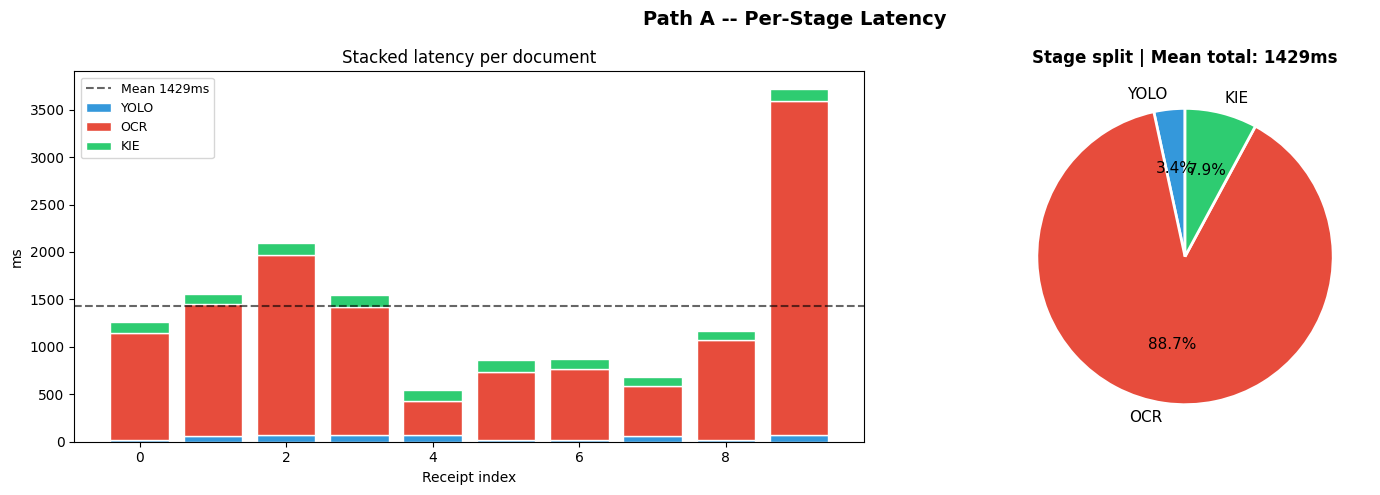

Saved -> /kaggle/working/doc-extraction-pipeline/outputs/annotated/phase5_latency.png


In [10]:
# Cell 11: Latency breakdown table + plot
print('Stage Latency Summary:')
print(f'  {"Stage":<15} {"Mean (ms)":>10} {"Min":>8} {"Max":>8}')
print(f'  {"-"*45}')
for stage, key in [("YOLO","yolo"),("OCR","ocr"),("KIE","kie"),("TOTAL","total")]:
    vals = all_timings[key]
    print(f'  {stage:<15} {np.mean(vals):>10.0f} {min(vals):>8.0f} {max(vals):>8.0f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Path A -- Per-Stage Latency', fontsize=14, fontweight='bold')

x = range(N)
axes[0].bar(x, all_timings['yolo'], label='YOLO',  color='#3498DB', edgecolor='white')
axes[0].bar(x, all_timings['ocr'],  label='OCR',   color='#E74C3C', edgecolor='white',
            bottom=all_timings['yolo'])
kie_bottom = [y+o for y,o in zip(all_timings['yolo'], all_timings['ocr'])]
axes[0].bar(x, all_timings['kie'],  label='KIE',   color='#2ECC71', edgecolor='white',
            bottom=kie_bottom)
axes[0].axhline(np.mean(all_timings['total']), color='black', linestyle='--',
                alpha=0.6, label=f'Mean {np.mean(all_timings["total"]):.0f}ms')
axes[0].set_xlabel('Receipt index'); axes[0].set_ylabel('ms')
axes[0].set_title('Stacked latency per document'); axes[0].legend(fontsize=9)

means = [np.mean(all_timings[k]) for k in ['yolo','ocr','kie']]
axes[1].pie(means, labels=['YOLO','OCR','KIE'],
            colors=['#3498DB','#E74C3C','#2ECC71'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize':11},
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title(f'Stage split | Mean total: {np.mean(all_timings["total"]):.0f}ms',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
save_path = OUTPUTS_DIR / 'annotated/phase5_latency.png'
plt.savefig(save_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved -> {save_path}')

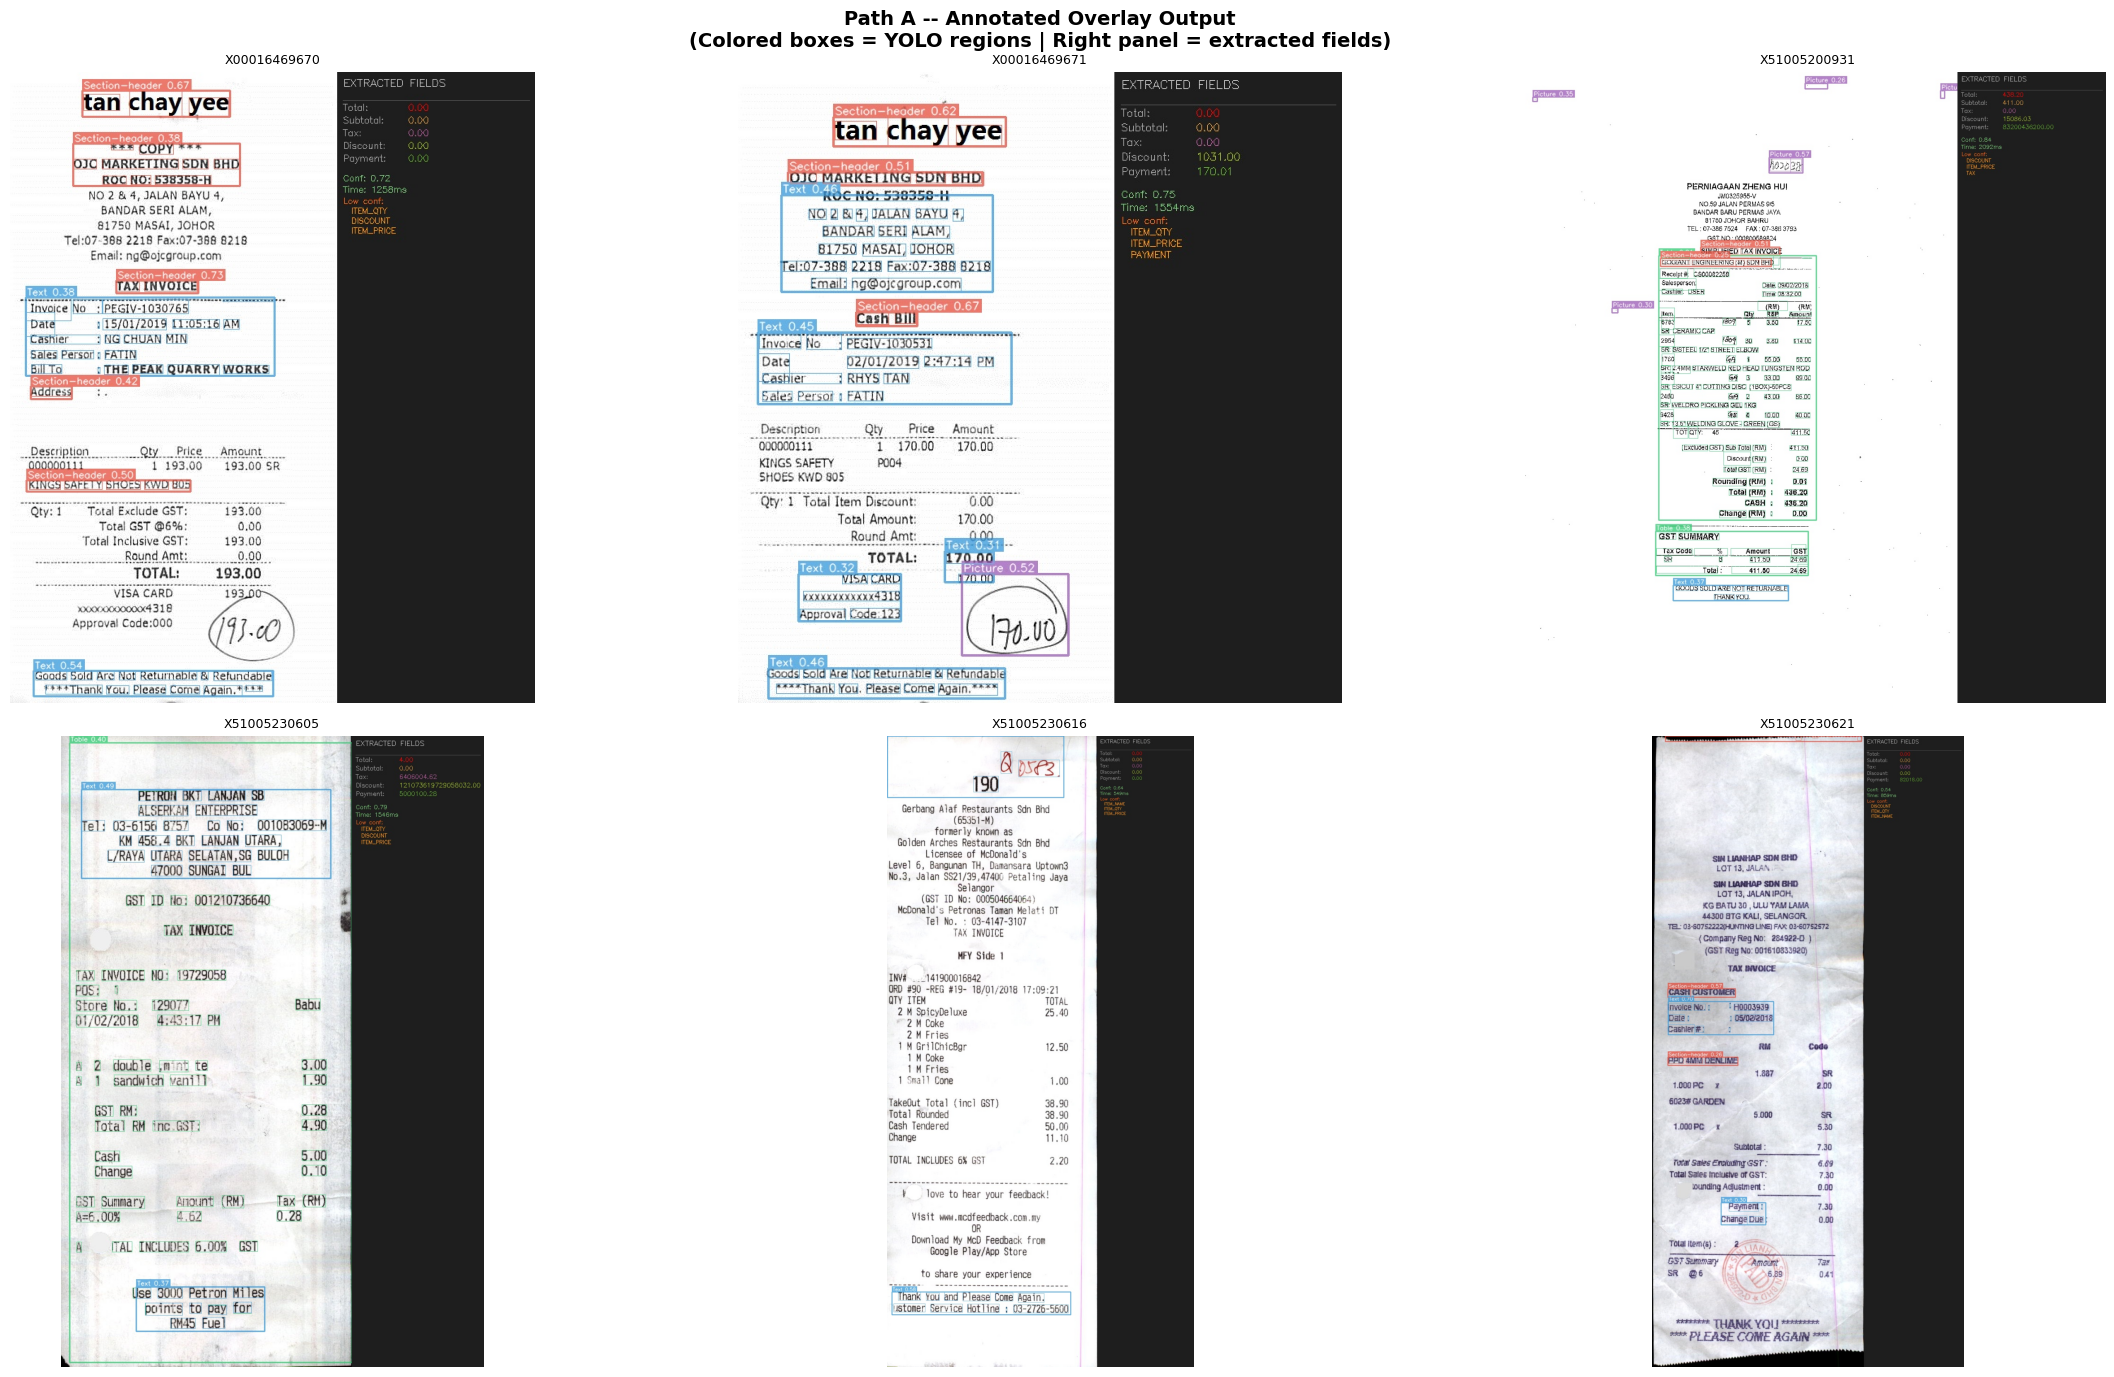

Saved -> /kaggle/working/doc-extraction-pipeline/outputs/annotated/phase5_overlay_grid.png


In [11]:
# Cell 12: Display annotated overlay grid (6 receipts)
overlay_files = sorted((OUTPUTS_DIR / 'annotated').glob('*_overlay.jpg'))[:6]

fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle('Path A -- Annotated Overlay Output\n'
             '(Colored boxes = YOLO regions | Right panel = extracted fields)',
             fontsize=14, fontweight='bold')

for ax, ov_path in zip(axes.flatten(), overlay_files):
    img = cv2.imread(str(ov_path))
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(ov_path.stem.replace('_overlay',''), fontsize=9)
    ax.axis('off')

for ax in axes.flatten()[len(overlay_files):]:
    ax.set_visible(False)

plt.tight_layout()
save_path = OUTPUTS_DIR / 'annotated/phase5_overlay_grid.png'
plt.savefig(save_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'Saved -> {save_path}')

In [12]:
# Cell 13: Evaluate total extraction vs SROIE ground truth
# SROIE provides company, date, address, total per receipt
# We compare our extracted totals against the ground truth totals

# Load SROIE key annotations
sroie_gt = {}
for txt_file in SROIE_ROOT.rglob('*.txt'):
    try:
        content = txt_file.read_text(encoding='utf-8', errors='ignore').strip()
        if not content: continue
        parsed = json.loads(content)
        if isinstance(parsed, dict) and 'total' in parsed:
            sroie_gt[txt_file.stem] = parsed
    except Exception:
        pass

print(f'SROIE ground truth loaded: {len(sroie_gt)} receipts')

# Compare predicted total vs ground truth total
total_matches  = []
eval_rows      = []

for row in batch_rows:
    stem = Path(row['file']).stem
    gt   = sroie_gt.get(stem, {})
    if not gt:
        continue

    gt_total   = float(str(gt.get('total', '0')).replace(',','').strip() or 0)
    pred_total = row['total']

    # Exact match within 1% tolerance
    if gt_total > 0:
        pct_err = abs(pred_total - gt_total) / gt_total * 100
        match   = pct_err < 5.0
    else:
        pct_err = 0
        match   = pred_total == 0

    total_matches.append(match)
    eval_rows.append({
        'file':      row['file'],
        'gt_total':  gt_total,
        'pred_total':pred_total,
        'pct_err':   round(pct_err, 2),
        'match':     match,
    })

if eval_rows:
    eval_df = pd.DataFrame(eval_rows)
    print(eval_df.to_string(index=False))
    acc = sum(total_matches) / len(total_matches) * 100
    print(f'\nTotal field accuracy (5% tolerance): {acc:.1f}% ({sum(total_matches)}/{len(total_matches)})')
else:
    print('No overlapping GT found -- check SROIE annotation path')
    acc = 0

SROIE ground truth loaded: 973 receipts
            file  gt_total  pred_total  pct_err  match
X00016469670.jpg    193.00         0.0   100.00  False
X00016469671.jpg    170.00         0.0   100.00  False
X51005200931.jpg    436.20       438.2     0.46   True
X51005230605.jpg      4.90         4.0    18.37  False
X51005230616.jpg     38.90         0.0   100.00  False
X51005230621.jpg      7.30         0.0   100.00  False
X51005230648.jpg      6.35         0.0   100.00  False
X51005230657.jpg      7.95         0.0   100.00  False
X51005230659.jpg      8.00         8.0     0.00   True
X51005268275.jpg    278.80         0.0   100.00  False

Total field accuracy (5% tolerance): 20.0% (2/10)


In [13]:
# Cell 14: Save all Phase 5 results
print('Saving Phase 5 results...')

phase5_results = {
    'phase':    5,
    'title':    'Path A Full Pipeline Integration',
    'pipeline': {
        'stage_1': 'YOLO26 layout detection',
        'stage_2': 'Tesseract OCR per region',
        'stage_3': 'LayoutLMv3 KIE',
        'stage_4': 'Pydantic JSON structuring',
        'stage_5': 'OpenCV annotated overlay',
    },
    'latency_ms': {
        'yolo_mean':  round(float(np.mean(all_timings['yolo'])),  1),
        'ocr_mean':   round(float(np.mean(all_timings['ocr'])),   1),
        'kie_mean':   round(float(np.mean(all_timings['kie'])),   1),
        'total_mean': round(float(np.mean(all_timings['total'])), 1),
        'target':     5000,
        'status':     'OK' if np.mean(all_timings['total']) < 5000 else 'SLOW',
    },
    'batch': {
        'n_receipts':   N,
        'avg_regions':  round(float(batch_df['regions'].mean()), 1),
        'avg_words':    round(float(batch_df['words'].mean()),   1),
        'avg_conf':     round(float(batch_df['confidence'].mean()), 3),
    },
    'sroie_total_accuracy': round(acc, 1) if eval_rows else None,
}

(RESULTS_DIR / 'phase5_results.json').write_text(json.dumps(phase5_results, indent=2))
print('  phase5_results.json saved')

md = f'''# Phase 5 Results -- Path A Full Pipeline Integration

## Pipeline Stages
1. YOLO26 layout detection
2. Tesseract OCR per region
3. LayoutLMv3 KIE (fine-tuned on CORD v2, F1=0.971)
4. Pydantic JSON structuring and validation
5. OpenCV annotated overlay

## Latency ({N} SROIE receipts)
| Stage | Mean (ms) |
|-------|-----------|
| YOLO detection | {np.mean(all_timings["yolo"]):.0f} |
| OCR | {np.mean(all_timings["ocr"]):.0f} |
| LayoutLMv3 KIE | {np.mean(all_timings["kie"]):.0f} |
| **Total** | **{np.mean(all_timings["total"]):.0f}** |
| Target | < 5000 |

## SROIE Total Field Accuracy: {round(acc,1) if eval_rows else "N/A"}%

## Source Files Written
- `src/layout_detector.py`
- `src/json_structurer.py`
- `src/visualiser.py`
- `src/pipeline.py`

## Next Step
Phase 6 -- Donut baseline (Path B) on CORD for comparison table
'''
(RESULTS_DIR / 'phase5_summary.md').write_text(md)
print('  phase5_summary.md saved')

print('\nAll Phase 5 output files:')
for f in sorted(WORKING_DIR.rglob('*')):
    if f.is_file() and f.stat().st_size > 1024:
        print(f'  [{f.stat().st_size//1024:>6} KB]  {f.relative_to(WORKING_DIR)}')

Saving Phase 5 results...
  phase5_results.json saved
  phase5_summary.md saved

All Phase 5 output files:
  [   207 KB]  outputs/annotated/X00016469670_overlay.jpg
  [   183 KB]  outputs/annotated/X00016469671_overlay.jpg
  [   233 KB]  outputs/annotated/X51005200931_overlay.jpg
  [   312 KB]  outputs/annotated/X51005230605_overlay.jpg
  [   266 KB]  outputs/annotated/X51005230616_overlay.jpg
  [   312 KB]  outputs/annotated/X51005230621_overlay.jpg
  [   213 KB]  outputs/annotated/X51005230648_overlay.jpg
  [   234 KB]  outputs/annotated/X51005230657_overlay.jpg
  [   241 KB]  outputs/annotated/X51005230659_overlay.jpg
  [   679 KB]  outputs/annotated/X51005268275_overlay.jpg
  [    62 KB]  outputs/annotated/phase5_latency.png
  [  1573 KB]  outputs/annotated/phase5_overlay_grid.png
  [     1 KB]  outputs/json/X00016469670.json
  [     1 KB]  outputs/json/X00016469671.json
  [     1 KB]  outputs/json/X51005200931.json
  [     1 KB]  outputs/json/X51005230605.json
  [     1 KB]  outpu

---
## Phase 5 Summary

In [14]:
# Cell 16: Phase 5 summary dashboard
print('=' * 65)
print('PHASE 5 COMPLETE -- Path A Full Pipeline Integration')
print('=' * 65)

print(f'''
  Pipeline: YOLO26 -> Tesseract -> LayoutLMv3 -> Pydantic JSON
  Test batch: {N} SROIE receipts

  Latency:
    YOLO detection:   {np.mean(all_timings["yolo"]):>6.0f} ms
    OCR:              {np.mean(all_timings["ocr"]):>6.0f} ms
    LayoutLMv3 KIE:   {np.mean(all_timings["kie"]):>6.0f} ms
    Total:            {np.mean(all_timings["total"]):>6.0f} ms (target < 5000 ms)

  Per document:
    Avg regions:      {batch_df["regions"].mean():.1f}
    Avg words:        {batch_df["words"].mean():.1f}
    Avg confidence:   {batch_df["confidence"].mean():.3f}
''')

print('  Source files written:')
src_files = ['layout_detector.py','ocr_engine.py','kie_model.py',
             'json_structurer.py','visualiser.py','pipeline.py','schema.py']
for fname in src_files:
    f = SRC_DIR / fname
    status = 'OK' if f.exists() else 'MISSING'
    print(f'  [{status}]  src/{fname}')

print(f'''
  NEXT STEP:
  1. Save output as Kaggle dataset: sdep-phase-5-output
  2. Phase 6 -- Donut baseline (Path B)
     Fine-tune Donut on CORD -> compare F1 vs Path A
     This completes the "modular vs end-to-end" paper narrative
''')
print('=' * 65)

PHASE 5 COMPLETE -- Path A Full Pipeline Integration

  Pipeline: YOLO26 -> Tesseract -> LayoutLMv3 -> Pydantic JSON
  Test batch: 10 SROIE receipts

  Latency:
    YOLO detection:       48 ms
    OCR:                1268 ms
    LayoutLMv3 KIE:      113 ms
    Total:              1429 ms (target < 5000 ms)

  Per document:
    Avg regions:      5.5
    Avg words:        90.3
    Avg confidence:   0.725

  Source files written:
  [OK]  src/layout_detector.py
  [OK]  src/ocr_engine.py
  [OK]  src/kie_model.py
  [OK]  src/json_structurer.py
  [OK]  src/visualiser.py
  [OK]  src/pipeline.py
  [OK]  src/schema.py

  NEXT STEP:
  1. Save output as Kaggle dataset: sdep-phase-5-output
  2. Phase 6 -- Donut baseline (Path B)
     Fine-tune Donut on CORD -> compare F1 vs Path A
     This completes the "modular vs end-to-end" paper narrative

